In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, color, filters, metrics
from pathlib import Path

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 4)
print('numpy version :', np.__version__)
     

numpy version : 2.2.5


shape : (512, 512)
dtype : uint8
min/max : 0 255
mean / std : 129.06072616577148 73.64484655630548


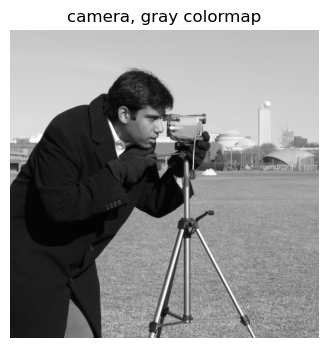

In [2]:
img = data.camera()  # uint8, (512, 512)
print('shape :', img.shape)
print('dtype :', img.dtype)
print('min/max :', img.min(), img.max())
print('mean / std :', img.mean(), img.std())

plt.imshow(img, cmap='gray')
plt.title('camera, gray colormap')
plt.axis('off')
plt.show()

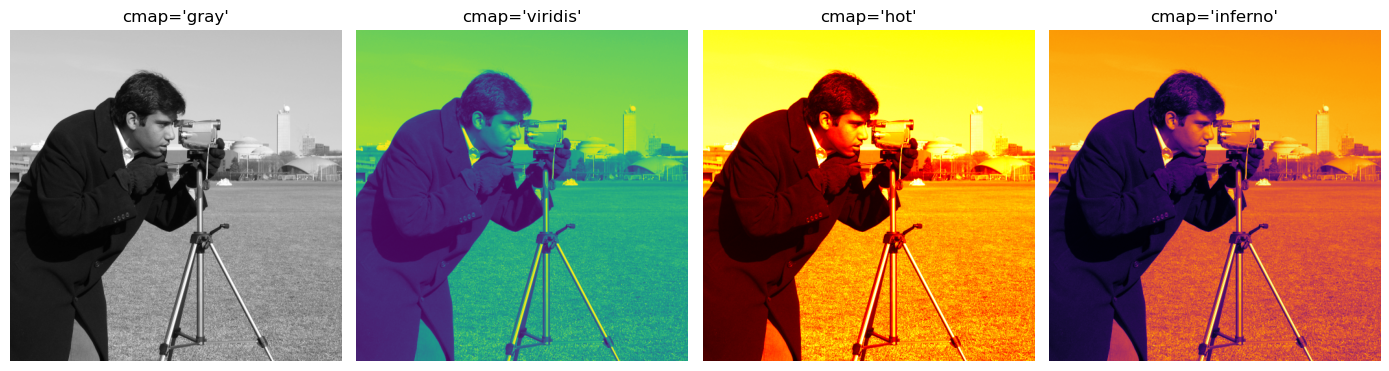

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, cmap in zip(axes, ['gray', 'viridis', 'hot', 'inferno']):
    ax.imshow(img, cmap=cmap)
    ax.set_title(f"cmap='{cmap}'")
    ax.axis('off')
plt.tight_layout(); plt.show()

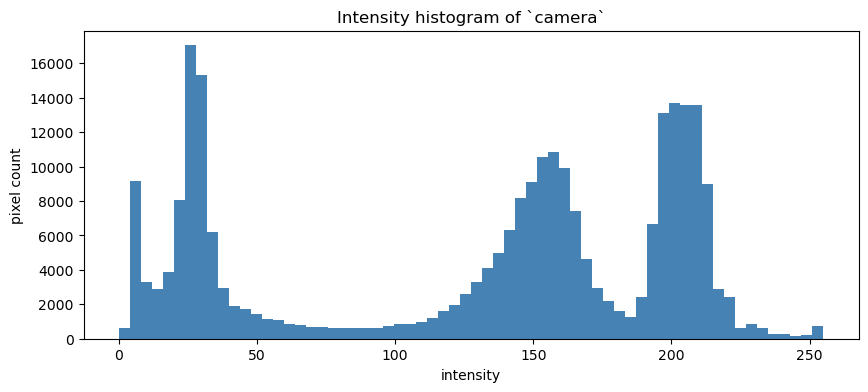

In [6]:
plt.hist(img.ravel(), bins=64, color='steelblue')
plt.title('Intensity histogram of `camera`')
plt.xlabel('intensity')
plt.ylabel('pixel count')
plt.show()

In [7]:
real_volume_path = Path('../data/brain.nii.gz')
volume = None

if real_volume_path.exists():
    import nibabel as nib
    nii = nib.load(real_volume_path)
    volume = np.asarray(nii.get_fdata())
    print('Loaded NIfTI:', real_volume_path)
    print('shape :', volume.shape, 'dtype:', volume.dtype)
    print('voxel spacing (mm):', nii.header.get_zooms())
else:
    # Synthetic phantom: three nested ellipsoids inside a 96^3 cube.
    N = 96
    z, y, x = np.indices((N, N, N)) - N//2
    r2 = (x/40)**2 + (y/35)**2 + (z/30)**2
    volume = np.zeros((N, N, N), dtype=np.float32)
    volume[r2 < 1.0] = 0.4   # outer
    volume[r2 < 0.5] = 0.7   # mid
    volume[r2 < 0.2] = 1.0   # inner
    print('No NIfTI found; using synthetic phantom.')
    print('shape :', volume.shape, 'dtype:', volume.dtype)

No NIfTI found; using synthetic phantom.
shape : (96, 96, 96) dtype: float32


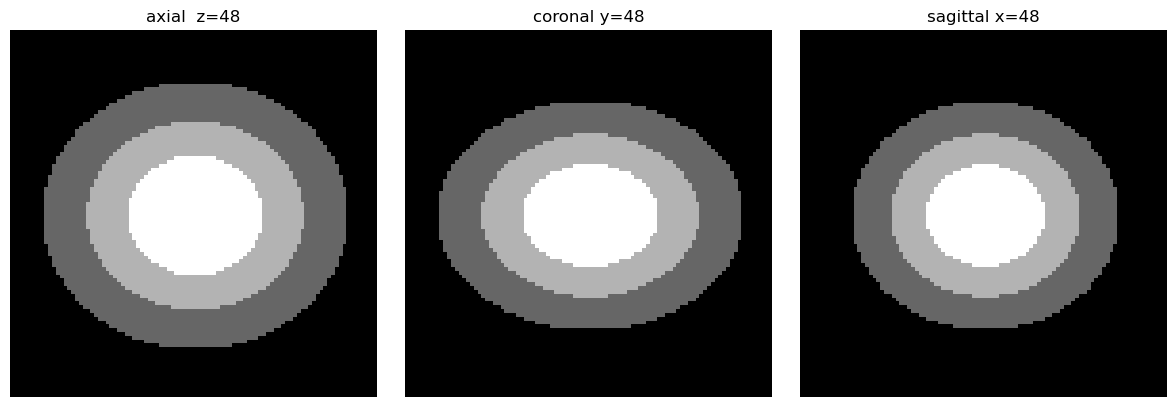

In [8]:
z0, y0, x0 = [s // 2 for s in volume.shape]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(volume[z0, :, :], cmap='gray');   axes[0].set_title(f'axial  z={z0}')
axes[1].imshow(volume[:, y0, :], cmap='gray');   axes[1].set_title(f'coronal y={y0}')
axes[2].imshow(volume[:, :, x0], cmap='gray');   axes[2].set_title(f'sagittal x={x0}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

PSNR noisy    = 20.45 dB
PSNR denoised = 26.41 dB  (gain: +5.96 dB)


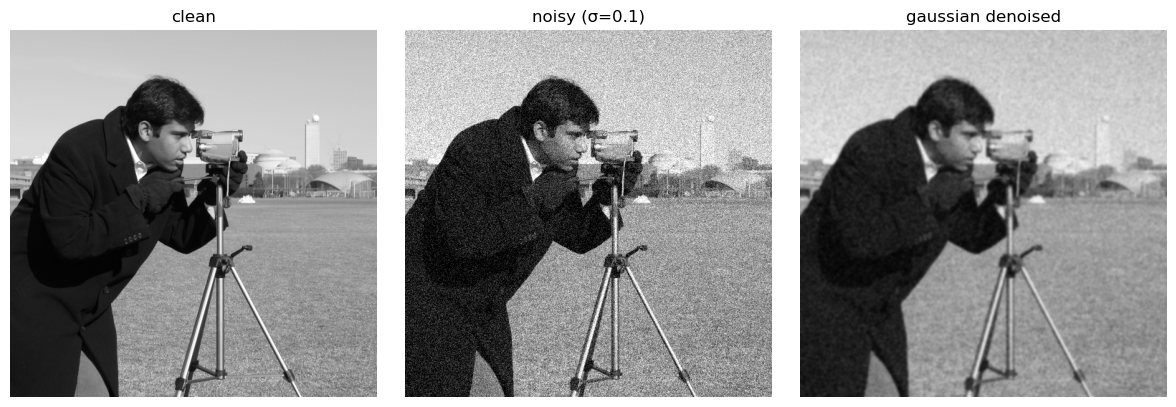

In [9]:

clean = img.astype(np.float32) / 255.0     # in [0, 1]
noisy = clean + np.random.normal(0.0, 0.10, size=clean.shape)
noisy = np.clip(noisy, 0, 1)

denoised = filters.gaussian(noisy, sigma=1.5)

psnr_noisy    = metrics.peak_signal_noise_ratio(clean, noisy,    data_range=1.0)
psnr_denoised = metrics.peak_signal_noise_ratio(clean, denoised, data_range=1.0)
print(f'PSNR noisy    = {psnr_noisy:5.2f} dB')
print(f'PSNR denoised = {psnr_denoised:5.2f} dB  (gain: {psnr_denoised - psnr_noisy:+.2f} dB)')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, t in zip(axes, [clean, noisy, denoised], ['clean', 'noisy (σ=0.1)', 'gaussian denoised']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

Exercise

Question 1 : Change the noise standard deviation to 0.05, 0.20, 0.40. Plot PSNR vs. noise level.

PSNR noisy    = 26.16 dB
PSNR denoised = 27.09 dB  (gain: +0.93 dB)


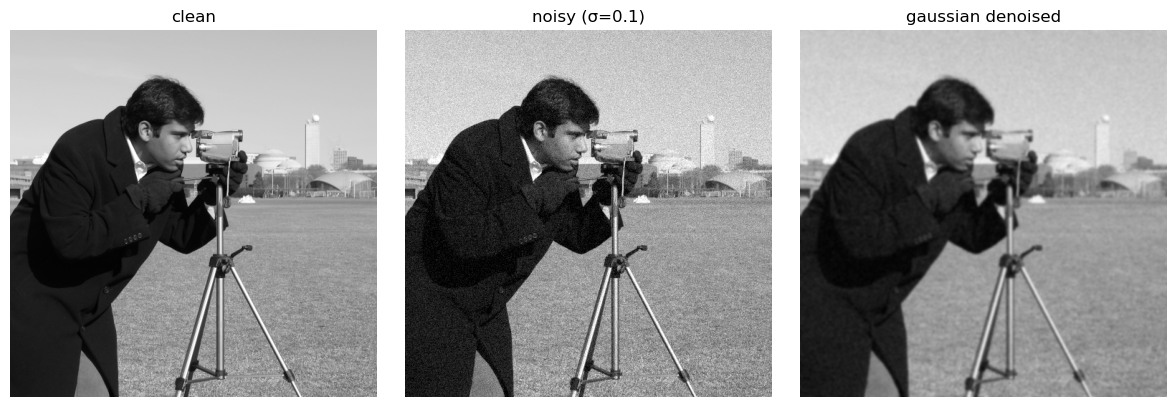

In [12]:

clean = img.astype(np.float32) / 255.0     # in [0, 1]
noisy = clean + np.random.normal(0.0, 0.05, size=clean.shape)
noisy = np.clip(noisy, 0, 1)

denoised = filters.gaussian(noisy, sigma=1.5)

psnr_noisy    = metrics.peak_signal_noise_ratio(clean, noisy,    data_range=1.0)
psnr_denoised = metrics.peak_signal_noise_ratio(clean, denoised, data_range=1.0)
print(f'PSNR noisy    = {psnr_noisy:5.2f} dB')
print(f'PSNR denoised = {psnr_denoised:5.2f} dB  (gain: {psnr_denoised - psnr_noisy:+.2f} dB)')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, t in zip(axes, [clean, noisy, denoised], ['clean', 'noisy (σ=0.1)', 'gaussian denoised']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

PSNR noisy    = 15.08 dB
PSNR denoised = 15.08 dB  (gain: +0.00 dB)


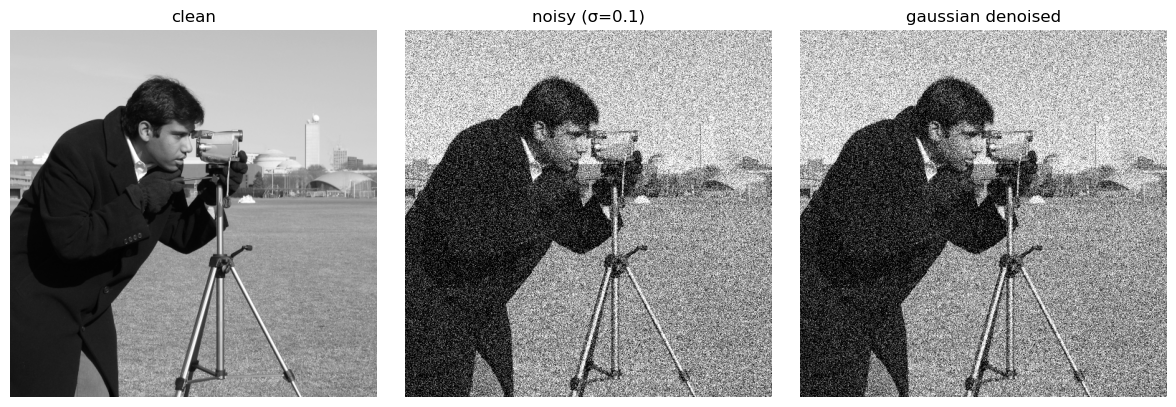

In [13]:

clean = img.astype(np.float32) / 255.0     # in [0, 1]
noisy = clean + np.random.normal(0.0, 0.20, size=clean.shape)
noisy = np.clip(noisy, 0, 1)

denoised = filters.gaussian(noisy, sigma=0.20)

psnr_noisy    = metrics.peak_signal_noise_ratio(clean, noisy,    data_range=1.0)
psnr_denoised = metrics.peak_signal_noise_ratio(clean, denoised, data_range=1.0)
print(f'PSNR noisy    = {psnr_noisy:5.2f} dB')
print(f'PSNR denoised = {psnr_denoised:5.2f} dB  (gain: {psnr_denoised - psnr_noisy:+.2f} dB)')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, t in zip(axes, [clean, noisy, denoised], ['clean', 'noisy (σ=0.1)', 'gaussian denoised']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()

PSNR noisy    = 10.37 dB
PSNR denoised = 19.39 dB  (gain: +9.02 dB)


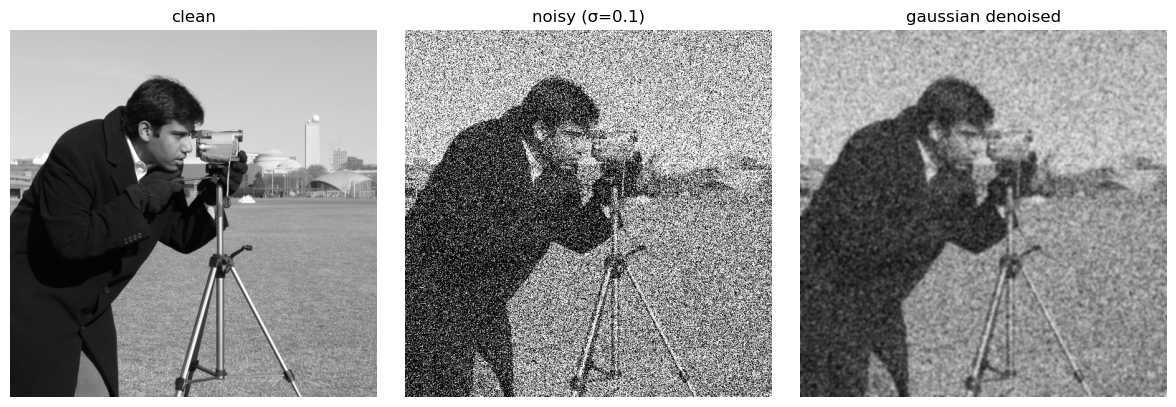

In [14]:

clean = img.astype(np.float32) / 255.0     # in [0, 1]
noisy = clean + np.random.normal(0.0, 0.40, size=clean.shape)
noisy = np.clip(noisy, 0, 1)

denoised = filters.gaussian(noisy, sigma=1.5)

psnr_noisy    = metrics.peak_signal_noise_ratio(clean, noisy,    data_range=1.0)
psnr_denoised = metrics.peak_signal_noise_ratio(clean, denoised, data_range=1.0)
print(f'PSNR noisy    = {psnr_noisy:5.2f} dB')
print(f'PSNR denoised = {psnr_denoised:5.2f} dB  (gain: {psnr_denoised - psnr_noisy:+.2f} dB)')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, t in zip(axes, [clean, noisy, denoised], ['clean', 'noisy (σ=0.1)', 'gaussian denoised']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()